In [1]:
# =============================================================================
# Notebook 01 — EDA Segmentado do Faturamento (Painel 32)
# Objetivo: validar que os 4 modelos segmentados fazem sentido +
#           identificar features chave por segmento
# =============================================================================

import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from datetime import datetime, timedelta
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Carrega .env do ml_workspace
for p in [Path('../.env'), Path('C:/ml_workspace/.env')]:
    if p.exists():
        load_dotenv(p)
        break

conn = psycopg2.connect(
    host=os.getenv('DB_HOST'),
    port=os.getenv('DB_PORT', '5432'),
    database=os.getenv('DB_NAME'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
)
print(f"Conectado ao PostgreSQL")
print(f"Python: {sys.version.split()[0]}")

Conectado ao PostgreSQL
Python: 3.11.9


In [2]:
# =============================================================================
# Carrega o faturamento por (data, tipo_atendimento) e pivota
# =============================================================================

df_longo = pd.read_sql("""
    SELECT *
    FROM public.vw_faturamento_diario_tipo
    ORDER BY data, tipo_atendimento
""", conn, parse_dates=['data'])

print(f"Shape longo: {df_longo.shape}")

# Nomes exatos confirmados nos SELECTs
SEGMENTOS = {
    'internado':     'Internado',
    'ps':            'Pronto socorro',
    'ambulatorial':  'Atendimento Ambulatorial',
    'externo':       'Externo',
}

# Separa em 4 DataFrames
dfs = {}
for codigo, nome in SEGMENTOS.items():
    d = df_longo[df_longo['tipo_atendimento'] == nome].copy()
    d = d.set_index('data').sort_index()
    # Reindexa pra ter todas as datas (preenche com 0 onde nao teve atendimento)
    datas_completas = pd.date_range(df_longo['data'].min(), df_longo['data'].max(), freq='D')
    d = d.reindex(datas_completas)
    d.index.name = 'data'
    # Preenche colunas numericas zeradas nos dias faltantes
    cols_num = d.select_dtypes(include='number').columns
    d[cols_num] = d[cols_num].fillna(0)
    d['tipo_atendimento'] = nome
    dfs[codigo] = d
    print(f"{codigo:>15}: {len(d)} dias | zeros: {(d['vl_total']==0).sum()} | "
          f"vl medio: R$ {d['vl_total'].mean():,.2f}")

Shape longo: (3180, 26)
      internado: 834 dias | zeros: 0 | vl medio: R$ 286,586.90
             ps: 834 dias | zeros: 0 | vl medio: R$ 99,055.42
   ambulatorial: 834 dias | zeros: 154 | vl medio: R$ 14,952.27
        externo: 834 dias | zeros: 2 | vl medio: R$ 15,314.32


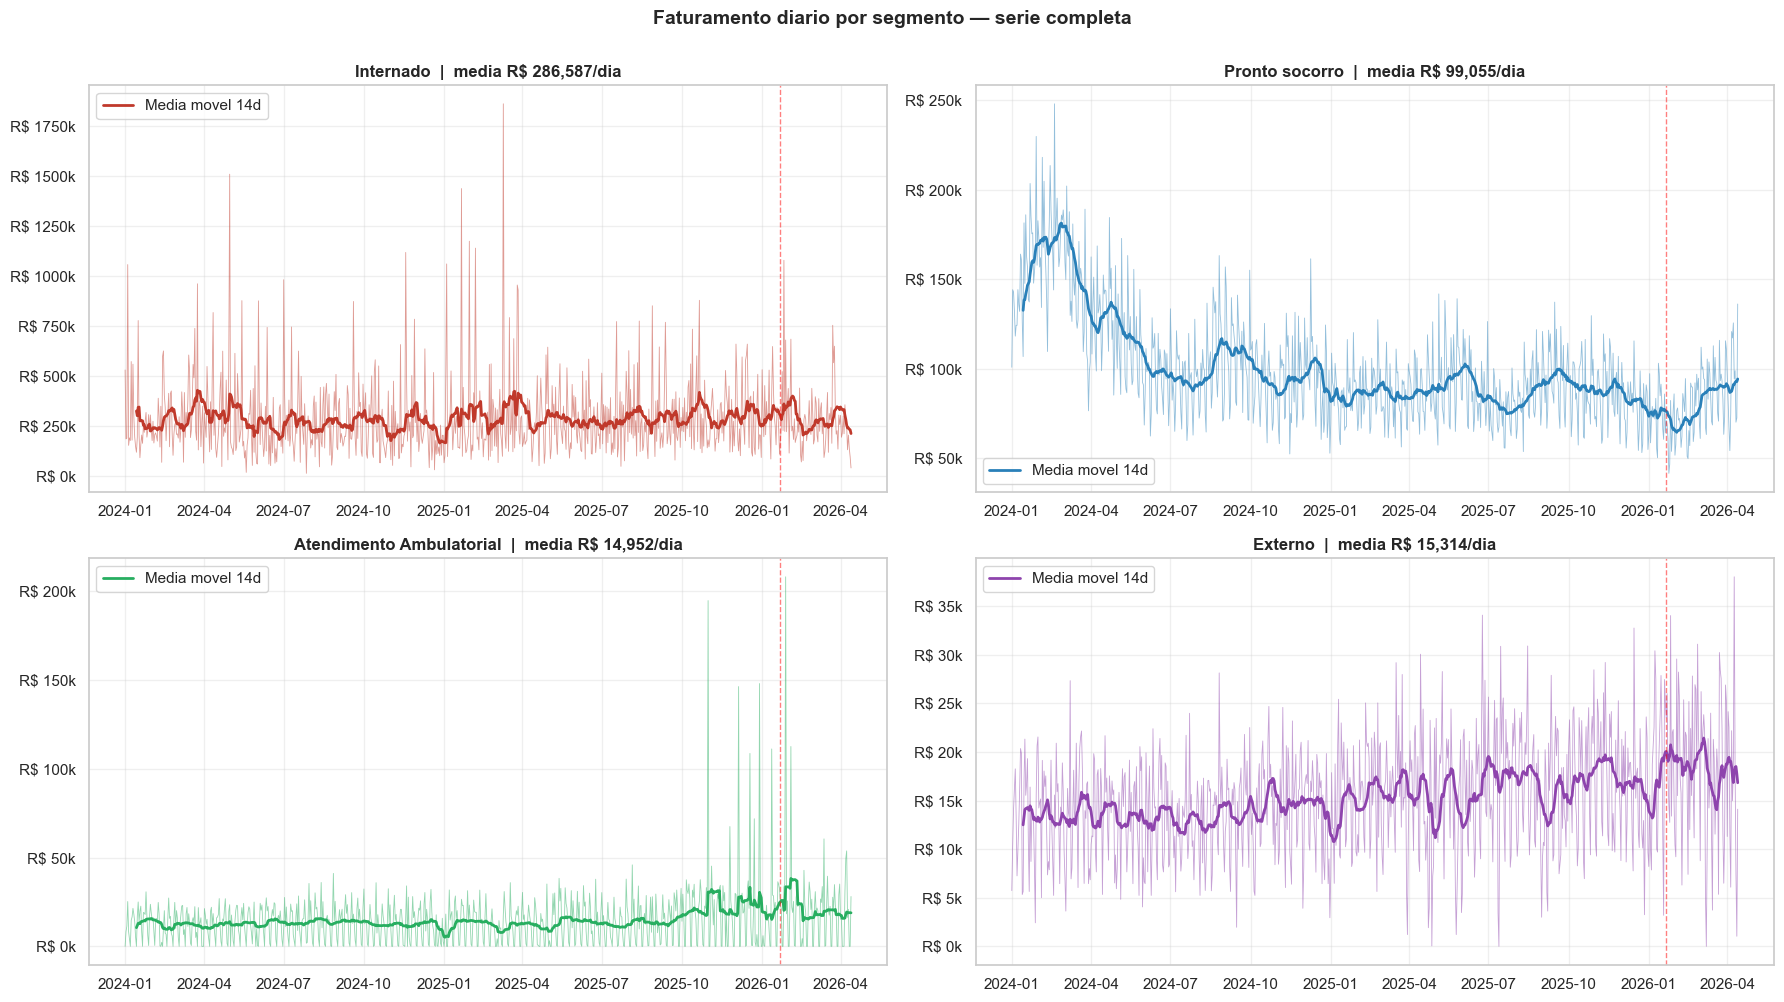

In [3]:
# =============================================================================
# Visualiza as 4 series juntas
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
cores = {'internado': '#c0392b', 'ps': '#2980b9',
         'ambulatorial': '#27ae60', 'externo': '#8e44ad'}

for ax, (codigo, d) in zip(axes.flatten(), dfs.items()):
    ax.plot(d.index, d['vl_total'], linewidth=0.6, color=cores[codigo], alpha=0.5)
    ax.plot(d.index, d['vl_total'].rolling(14).mean(), linewidth=2,
            color=cores[codigo], label='Media movel 14d')

    # Linha vertical na remocao da Cardiologia do PS
    ax.axvline(pd.Timestamp('2026-01-21'), color='red', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_title(f'{SEGMENTOS[codigo]}  |  media R$ {d["vl_total"].mean():,.0f}/dia',
                 fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda x, _: f'R$ {x/1000:.0f}k'))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Faturamento diario por segmento — serie completa', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

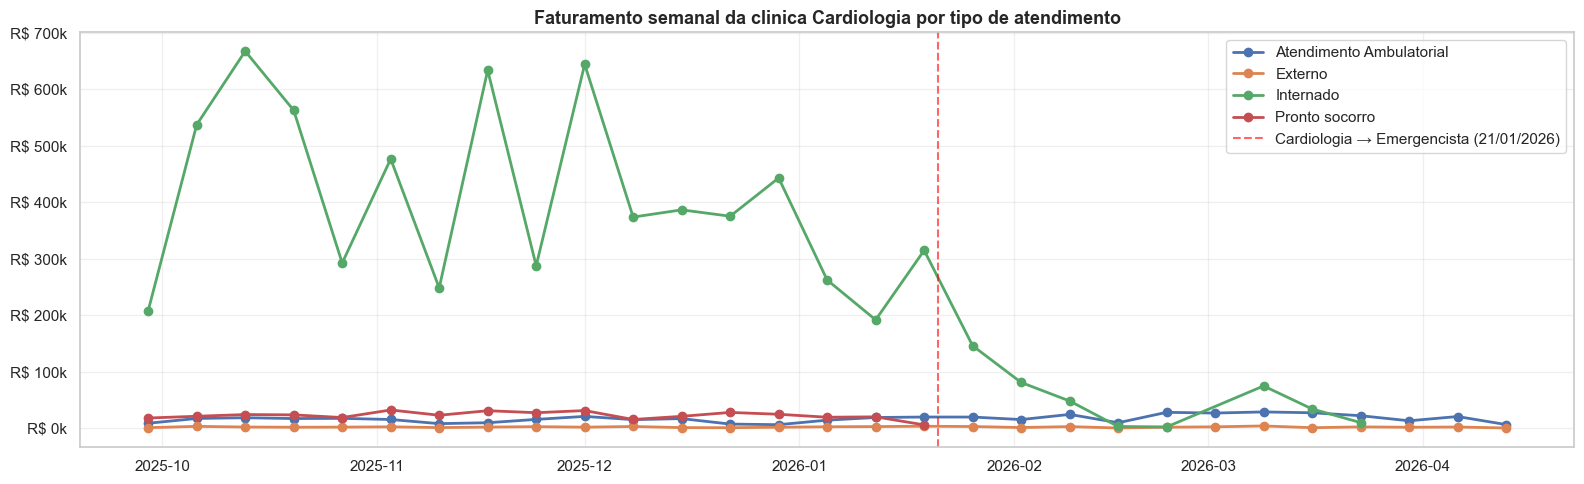


Expectativa confirmada se:
  - PS da Cardiologia cai a zero apos 21/01/2026
  - Internado/Externo/Ambulatorial de Cardiologia CONTINUA normal


In [4]:
# =============================================================================
# Teste estrutural: confirmar que Cardiologia so some no PS
# =============================================================================

teste_cardio = pd.read_sql("""
    SELECT
        DATE_TRUNC('week', dt_entrada)::date AS semana,
        tipo_atendimento,
        SUM(vl_produzido) AS vl
    FROM public.ml_faturamento
    WHERE ds_clinica = 'Cardiologia'
      AND dt_entrada >= '2025-10-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""", conn, parse_dates=['semana'])

fig, ax = plt.subplots(figsize=(16, 5))
for tipo in teste_cardio['tipo_atendimento'].unique():
    d = teste_cardio[teste_cardio['tipo_atendimento'] == tipo]
    ax.plot(d['semana'], d['vl'], 'o-', label=tipo, linewidth=2)

ax.axvline(pd.Timestamp('2026-01-21'), color='red', linestyle='--', alpha=0.6,
           label='Cardiologia → Emergencista (21/01/2026)')
ax.set_title('Faturamento semanal da clinica Cardiologia por tipo de atendimento',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}k'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nExpectativa confirmada se:")
print("  - PS da Cardiologia cai a zero apos 21/01/2026")
print("  - Internado/Externo/Ambulatorial de Cardiologia CONTINUA normal")

In [5]:
# =============================================================================
# Features candidatas: quais tem maior correlacao com vl_total de cada segmento?
# =============================================================================

def features_corr(d, nome, top_n=15):
    # Cria features lag basicas para avaliacao
    d = d.copy()
    for col_alvo in ['vl_total', 'qt_atendimentos']:
        for lag in [1, 7, 14]:
            d[f'{col_alvo}_lag_{lag}'] = d[col_alvo].shift(lag)

    # Features que ja temos na view
    cand = [c for c in d.columns if c.startswith(('vl_', 'qt_atend', 'ticket_'))
            and c != 'vl_total']

    corrs = d[cand + ['vl_total']].corr()['vl_total'].drop('vl_total')
    corrs = corrs.sort_values(key=abs, ascending=False).head(top_n)

    print(f"\n{'='*60}\n{nome}\n{'='*60}")
    for feat, corr in corrs.items():
        bar = '#' * int(abs(corr) * 40)
        print(f"  {feat:<35} {corr:>+.3f}  {bar}")
    return corrs

corrs_por_seg = {}
for codigo, d in dfs.items():
    corrs_por_seg[codigo] = features_corr(d, SEGMENTOS[codigo])


Internado
  vl_uti                              +0.884  ###################################
  ticket_medio                        +0.831  #################################
  vl_materiais                        +0.802  ################################
  vl_honorarios                       +0.769  ##############################
  vl_medicamentos                     +0.748  #############################
  vl_laboratorio_setor                +0.718  ############################
  vl_diarias                          +0.699  ###########################
  vl_pacotes                          +0.576  #######################
  vl_opme                             +0.502  ####################
  vl_hemodinamica                     +0.476  ###################
  vl_radiologia_setor                 +0.461  ##################
  vl_centro_cirurgico                 +0.457  ##################
  vl_internacao_setor                 +0.451  ##################
  qt_atend_hemodinamica               +0.422  ##

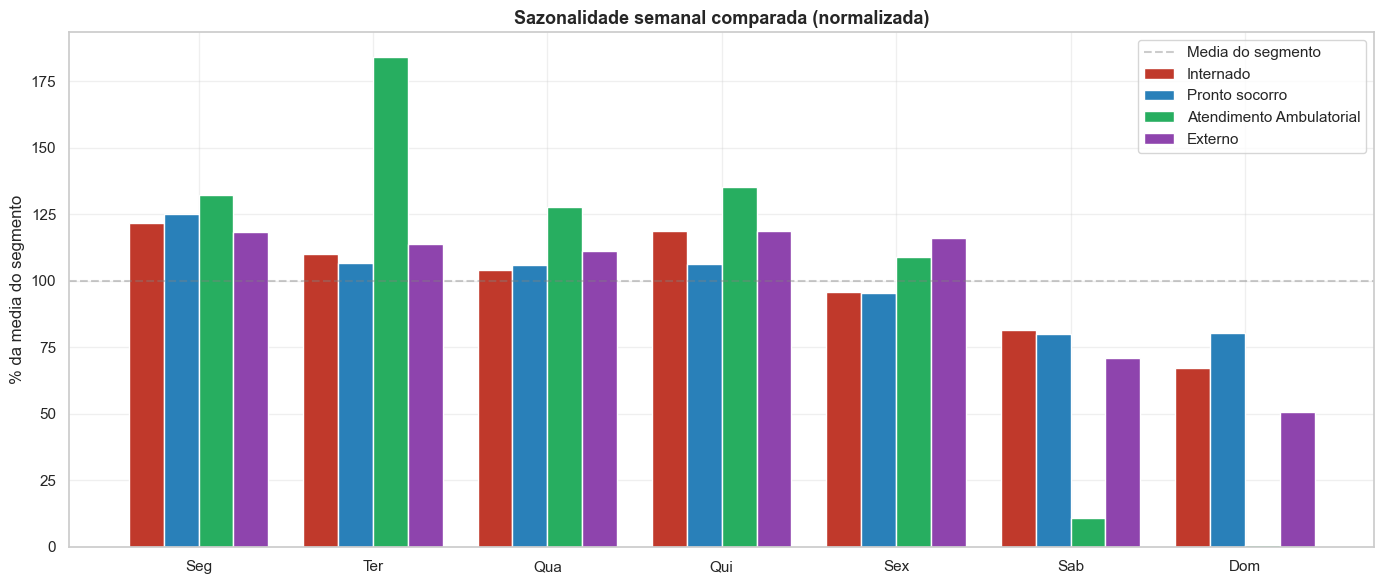

In [6]:
# =============================================================================
# Cada segmento reage ao dia da semana diferente?
# =============================================================================

dias_pt = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(7)
w = 0.2

for i, (codigo, d) in enumerate(dfs.items()):
    d = d.copy()
    d['dow'] = d.index.dayofweek
    medias = d.groupby('dow')['vl_total'].mean().reindex(range(7)).fillna(0)
    # Normaliza para % da media geral (facilita comparacao visual)
    medias_pct = medias / medias.mean() * 100
    ax.bar(x + i*w - 1.5*w, medias_pct, w, label=SEGMENTOS[codigo], color=cores[codigo])

ax.set_xticks(x)
ax.set_xticklabels(dias_pt)
ax.axhline(100, color='gray', linestyle='--', alpha=0.4, label='Media do segmento')
ax.set_ylabel('% da media do segmento')
ax.set_title('Sazonalidade semanal comparada (normalizada)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

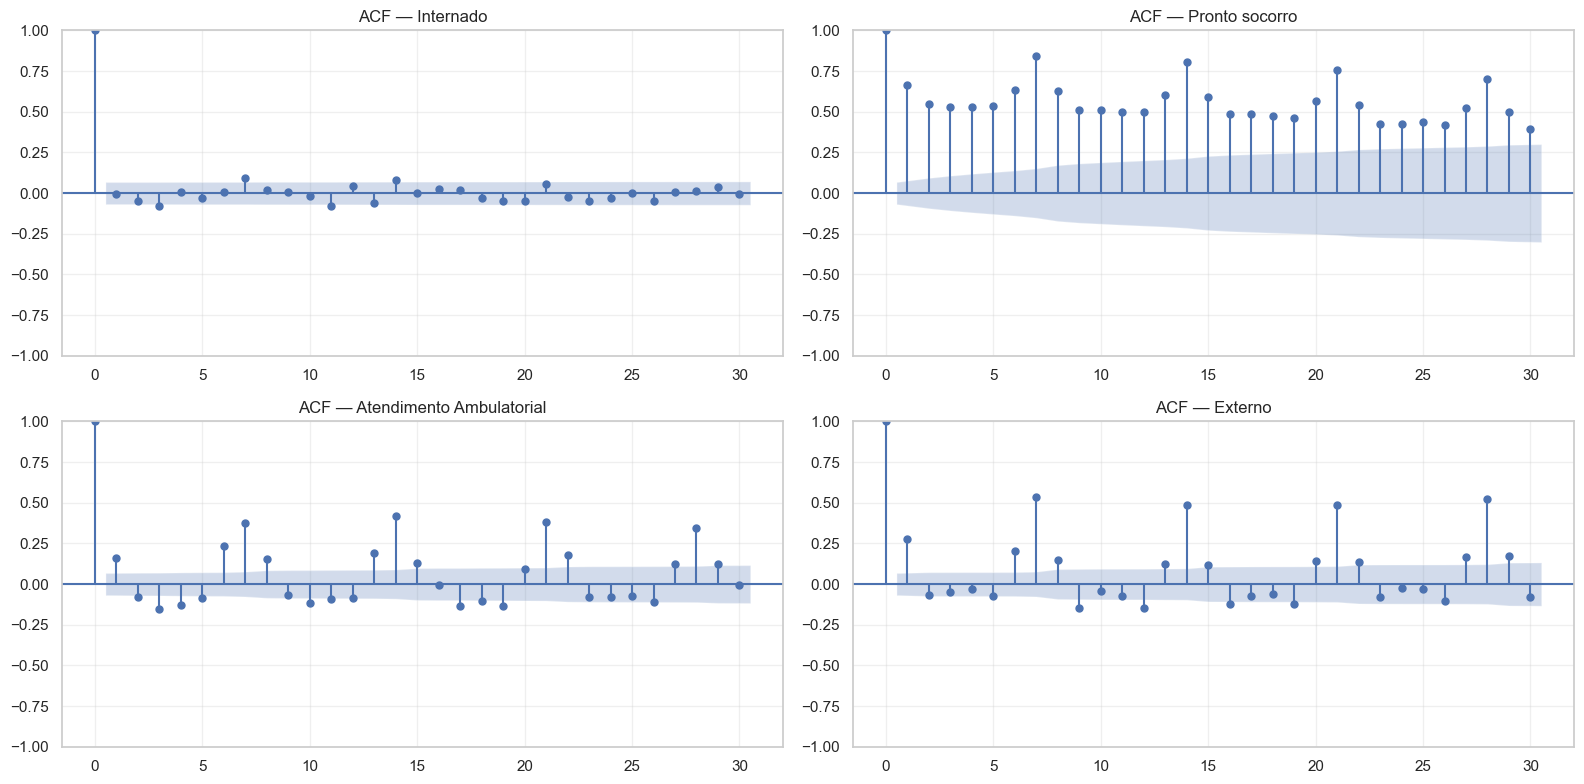


Leitura:
  Lags significativos (fora da faixa azul) = bons candidatos a features lag
  Lag 7 alto = sazonalidade semanal forte
  Lag 14/21 alto = ciclo quinzenal


In [7]:
# =============================================================================
# ACF para cada segmento (decide os lags a usar no modelo)
# =============================================================================

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (codigo, d) in zip(axes.flatten(), dfs.items()):
    serie = d['vl_total'].dropna()
    plot_acf(serie, lags=30, ax=ax, title=f'ACF — {SEGMENTOS[codigo]}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLeitura:")
print("  Lags significativos (fora da faixa azul) = bons candidatos a features lag")
print("  Lag 7 alto = sazonalidade semanal forte")
print("  Lag 14/21 alto = ciclo quinzenal")

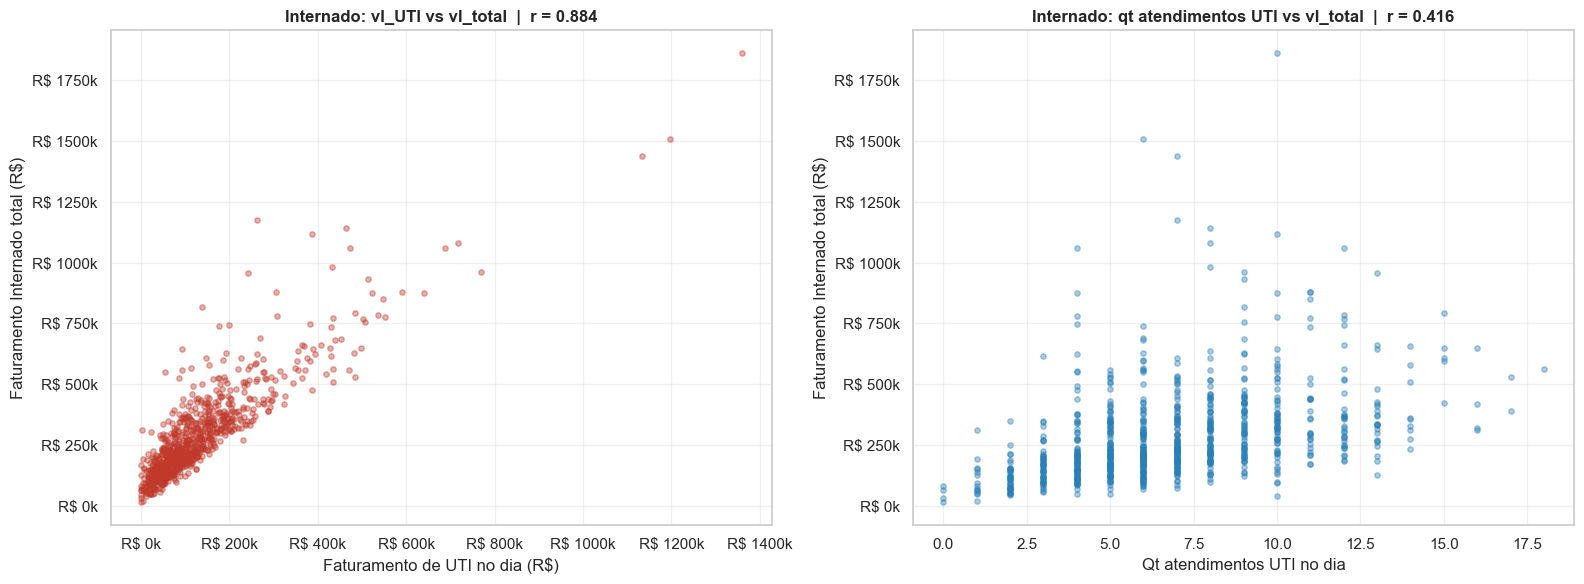


Correlacao vl_uti → vl_internado: 0.884
Correlacao qt_uti → vl_internado: 0.416
✓ UTI e feature forte pro modelo de Internados — confirmado


In [8]:
# =============================================================================
# Proposta: mix de setor explica variabilidade do faturamento de Internados?
# =============================================================================

d_int = dfs['internado'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter vl_uti vs vl_total
axes[0].scatter(d_int['vl_uti'], d_int['vl_total'], alpha=0.4, s=15, c='#c0392b')
corr_uti = d_int[['vl_uti','vl_total']].corr().iloc[0,1]
axes[0].set_title(f'Internado: vl_UTI vs vl_total  |  r = {corr_uti:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Faturamento de UTI no dia (R$)')
axes[0].set_ylabel('Faturamento Internado total (R$)')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}k'))
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}k'))
axes[0].grid(alpha=0.3)

# Scatter qt_uti vs vl_total
axes[1].scatter(d_int['qt_atend_uti'], d_int['vl_total'], alpha=0.4, s=15, c='#2980b9')
corr_qt = d_int[['qt_atend_uti','vl_total']].corr().iloc[0,1]
axes[1].set_title(f'Internado: qt atendimentos UTI vs vl_total  |  r = {corr_qt:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Qt atendimentos UTI no dia')
axes[1].set_ylabel('Faturamento Internado total (R$)')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}k'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelacao vl_uti → vl_internado: {corr_uti:.3f}")
print(f"Correlacao qt_uti → vl_internado: {corr_qt:.3f}")
if corr_uti > 0.5 or corr_qt > 0.5:
    print("✓ UTI e feature forte pro modelo de Internados — confirmado")

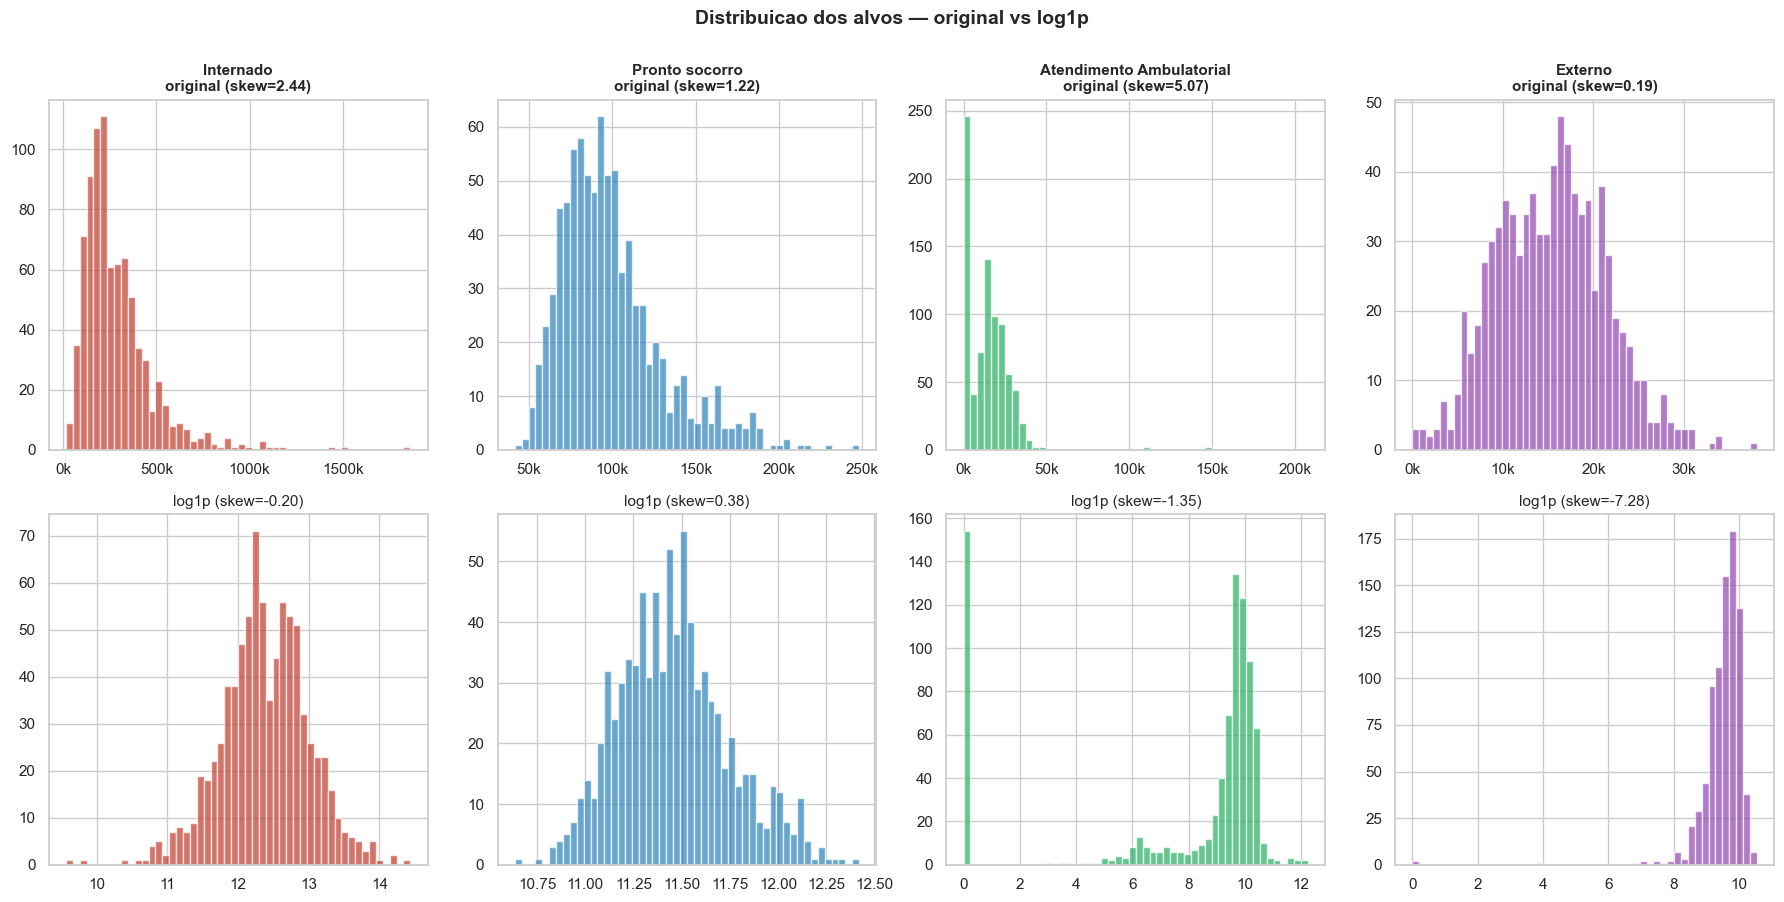


Interpretacao:
  skew > 1.0 → cauda longa, log1p ajuda
  skew entre 0.5 e 1.0 → borderline, log1p pode ajudar
  skew < 0.5 → distribuicao simetrica, log1p desnecessario


In [9]:
# =============================================================================
# Histograma dos alvos: justificam log1p?
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col, (codigo, d) in enumerate(dfs.items()):
    serie = d['vl_total']
    # Original
    axes[0, col].hist(serie, bins=50, color=cores[codigo], alpha=0.7)
    axes[0, col].set_title(f'{SEGMENTOS[codigo]}\noriginal (skew={serie.skew():.2f})',
                           fontsize=11, fontweight='bold')
    axes[0, col].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k'))
    # Log1p
    axes[1, col].hist(np.log1p(serie), bins=50, color=cores[codigo], alpha=0.7)
    axes[1, col].set_title(f'log1p (skew={np.log1p(serie).skew():.2f})',
                           fontsize=11)

plt.suptitle('Distribuicao dos alvos — original vs log1p', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nInterpretacao:")
print("  skew > 1.0 → cauda longa, log1p ajuda")
print("  skew entre 0.5 e 1.0 → borderline, log1p pode ajudar")
print("  skew < 0.5 → distribuicao simetrica, log1p desnecessario")

PS - Faturamento medio diario:
  Antes (nov/2025 a 20jan/2026):  R$ 78,915.82
  Depois (21jan a 22mar/2026):    R$ 77,796.07
  Delta:                          R$ -1,119.74 (-1.4%)

✓ Mudanca de -1.4% < 10% — impacto pequeno


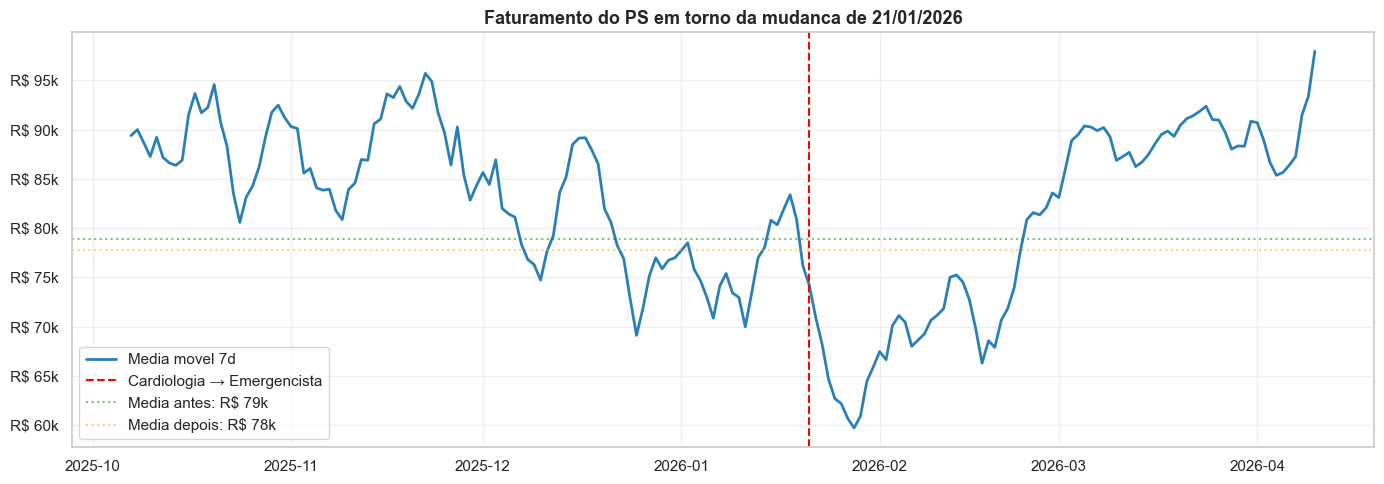

In [10]:
# =============================================================================
# Estimativa: quanto o PS perdeu com a saida da Cardiologia em 21/01/2026?
# =============================================================================

d_ps = dfs['ps'].copy()

# Antes vs depois da mudanca (janelas comparaveis de ~60 dias)
antes = d_ps.loc['2025-11-22':'2026-01-20', 'vl_total'].mean()
depois = d_ps.loc['2026-01-22':'2026-03-22', 'vl_total'].mean()
delta = depois - antes
delta_pct = delta / antes * 100

print(f"PS - Faturamento medio diario:")
print(f"  Antes (nov/2025 a 20jan/2026):  R$ {antes:,.2f}")
print(f"  Depois (21jan a 22mar/2026):    R$ {depois:,.2f}")
print(f"  Delta:                          R$ {delta:+,.2f} ({delta_pct:+.1f}%)")
print()
if abs(delta_pct) > 10:
    print(f"⚠ Mudanca de {delta_pct:+.1f}% > 10% — flag_clinica_removida ESSENCIAL pro modelo PS")
else:
    print(f"✓ Mudanca de {delta_pct:+.1f}% < 10% — impacto pequeno")

# Plot antes/depois
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d_ps.loc['2025-10-01':'2026-04-10'].index,
        d_ps.loc['2025-10-01':'2026-04-10', 'vl_total'].rolling(7).mean(),
        linewidth=2, color='#2980b9', label='Media movel 7d')
ax.axvline(pd.Timestamp('2026-01-21'), color='red', linestyle='--',
           label='Cardiologia → Emergencista')
ax.axhline(antes, color='green', linestyle=':', alpha=0.5, label=f'Media antes: R$ {antes/1000:.0f}k')
ax.axhline(depois, color='orange', linestyle=':', alpha=0.5, label=f'Media depois: R$ {depois/1000:.0f}k')
ax.set_title('Faturamento do PS em torno da mudanca de 21/01/2026',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}k'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# =============================================================================
# Qual seria o MAE se so usassemos "mesmo dia da semana passada"?
# Esse vira o piso a ser batido pelos modelos LightGBM.
# =============================================================================

from sklearn.metrics import mean_absolute_error

print(f"{'Segmento':<22} {'MAE baseline (lag 7d)':<25} {'% do alvo':<12}")
print("-" * 60)
for codigo, d in dfs.items():
    # Usa so os ultimos 60 dias como "teste" do baseline
    d_teste = d.iloc[-60:].copy()
    d_teste['pred'] = d_teste['vl_total'].shift(7)
    d_teste = d_teste.dropna(subset=['pred'])
    mae = mean_absolute_error(d_teste['vl_total'], d_teste['pred'])
    media = d_teste['vl_total'].mean()
    pct = mae / media * 100 if media > 0 else 0
    print(f"{SEGMENTOS[codigo]:<22} R$ {mae:>15,.2f}      {pct:>6.1f}%")

print("\nNosso LightGBM precisa bater esses numeros.")
print("Expectativa razoavel: 30-50% melhor que o baseline.")

Segmento               MAE baseline (lag 7d)     % do alvo   
------------------------------------------------------------
Internado              R$      129,757.66        48.0%
Pronto socorro         R$        8,936.53        10.0%
Atendimento Ambulatorial R$        8,214.44        44.7%
Externo                R$        6,373.69        35.8%

Nosso LightGBM precisa bater esses numeros.
Expectativa razoavel: 30-50% melhor que o baseline.


In [12]:
# =============================================================================
# SUMARIO DOS ACHADOS
# =============================================================================

print("=" * 70)
print("DECISOES PRO NOTEBOOK 02 (TREINO)")
print("=" * 70)

for codigo, d in dfs.items():
    nome = SEGMENTOS[codigo]
    serie = d['vl_total']
    skew = serie.skew()
    zeros = (serie == 0).sum()

    top3_corrs = corrs_por_seg[codigo].head(3)
    top3_str = ', '.join([f"{k}({v:+.2f})" for k, v in top3_corrs.items()])

    print(f"\n{'▼ ' + nome}")
    print(f"  Media/dia:        R$ {serie.mean():,.2f}")
    print(f"  Skew:             {skew:.2f}  →  {'usar log1p' if skew > 0.8 else 'log1p opcional'}")
    print(f"  Dias zerados:     {zeros}  ({'normal' if codigo == 'ambulatorial' else 'conferir se >0'})")
    print(f"  Top 3 features:   {top3_str}")

conn.close()

print("\n" + "=" * 70)
print("Arquitetura confirmada: 4 modelos separados, LightGBM, horizonte 7 dias")
print("Proximo passo: Notebook 02 — treino + serializacao dos .pkl")
print("=" * 70)

DECISOES PRO NOTEBOOK 02 (TREINO)

▼ Internado
  Media/dia:        R$ 286,586.90
  Skew:             2.44  →  usar log1p
  Dias zerados:     0  (conferir se >0)
  Top 3 features:   vl_uti(+0.88), ticket_medio(+0.83), vl_materiais(+0.80)

▼ Pronto socorro
  Media/dia:        R$ 99,055.42
  Skew:             1.22  →  usar log1p
  Dias zerados:     0  (conferir se >0)
  Top 3 features:   vl_ps_setor(+0.99), qt_atendimentos(+0.93), vl_materiais(+0.92)

▼ Atendimento Ambulatorial
  Media/dia:        R$ 14,952.27
  Skew:             5.07  →  usar log1p
  Dias zerados:     154  (normal)
  Top 3 features:   vl_medicamentos(+0.79), vl_ambulatorio_setor(+0.66), vl_honorarios(+0.60)

▼ Externo
  Media/dia:        R$ 15,314.32
  Skew:             0.19  →  log1p opcional
  Dias zerados:     2  (conferir se >0)
  Top 3 features:   vl_radiologia_setor(+0.98), qt_atendimentos(+0.86), vl_laboratorio_setor(+0.62)

Arquitetura confirmada: 4 modelos separados, LightGBM, horizonte 7 dias
Proximo passo: Not